In [1]:
import pandas as pd
from chainconsumer import Chain, ChainConsumer, Truth
import numpy as np

from astropy import units as u
from odisseo.units import CodeUnits

Parameter $M_{plummer}$ in chain Simulated Feedback is not constrained


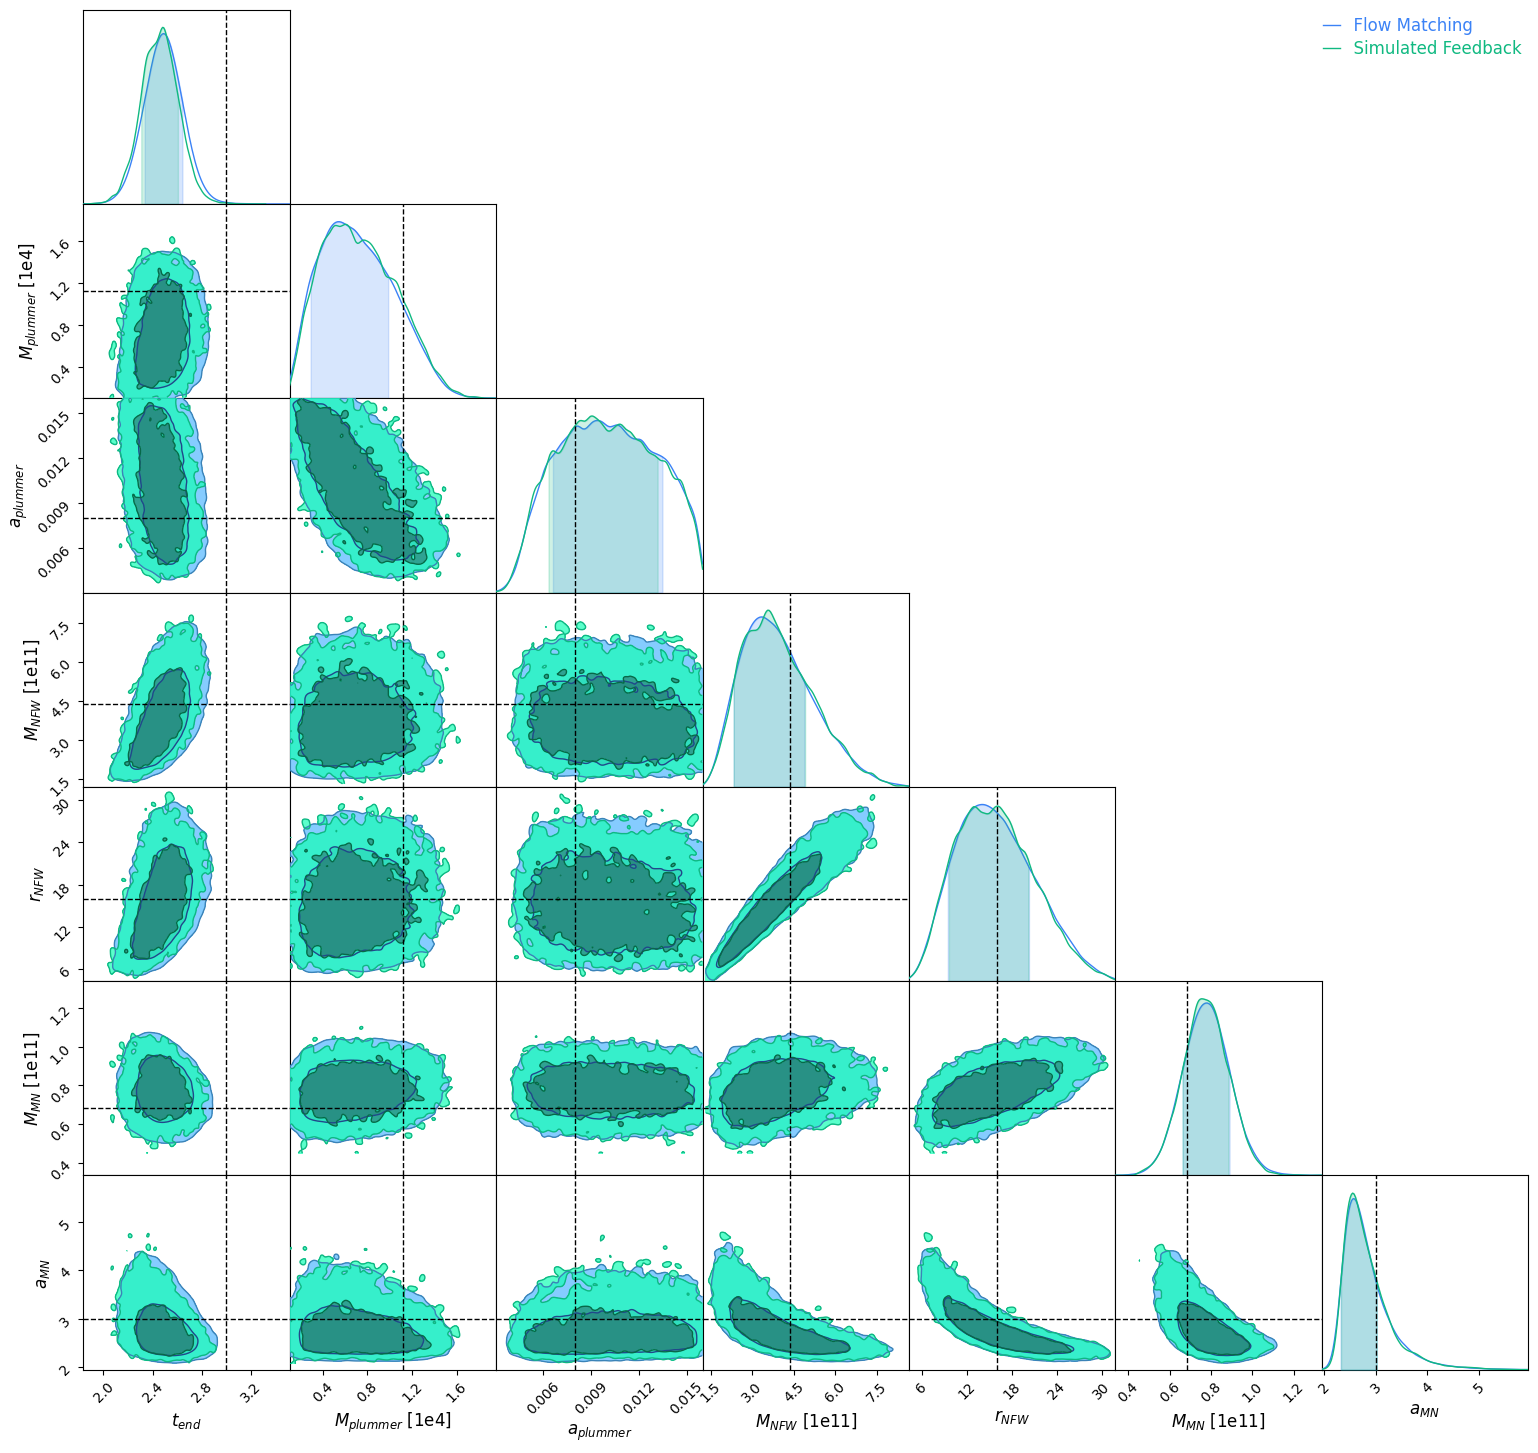

In [ ]:
data_FM = np.load('./logs/Odisseo_OT_AllParameters/pictures/true_observation_prediction.npz')['predicted_theta']

data_SimFeedback = np.load('./logs/OdisseoSimulatorOT_AllParameters/pictures/true_observation_prediction.npz')['predicted_theta']



true_theta = np.load('./logs/OdisseoSimulatorOT_AllParameters/pictures/true_observation_prediction.npz')['true_theta']
labels = ['$t_{end}$', '$M_{plummer}$', '$a_{plummer}$', '$M_{NFW}$', '$r_{NFW}$', '$M_{MN}$', '$a_{MN}$']

df_FM = pd.DataFrame(data_FM, columns=labels)
df_FM = df_FM.astype(float)

df_SimFeedback = pd.DataFrame(data_SimFeedback, columns=labels)
df_SimFeedback = df_SimFeedback.astype(float)


code_length = 10 * u.kpc
code_mass = 1e4 * u.Msun
G = 1
code_time = 3 * u.Gyr
code_units = CodeUnits(code_length, code_mass, G=1, unit_time = code_time )  

c = ChainConsumer()
c.add_chain(Chain(samples=df_FM, name="Flow Matching", ), )
c.add_chain(Chain(samples=df_SimFeedback, name="Simulated Feedback", ), )
c.add_truth(Truth(location={
        '$t_{end}$': true_theta[0] * code_units.code_time.to(u.Gyr),
        '$M_{plummer}$': true_theta[1] * code_units.code_mass.to(u.Msun),
        '$a_{plummer}$': true_theta[2] * code_units.code_length.to(u.kpc),
        '$M_{NFW}$': true_theta[3] * code_units.code_mass.to(u.Msun),
        '$r_{NFW}$': true_theta[4] * code_units.code_length.to(u.kpc),
        '$M_{MN}$': true_theta[5] * code_units.code_mass.to(u.Msun),
        '$a_{MN}$': true_theta[6] * code_units.code_length.to(u.kpc),
}))
fig = c.plotter.plot()   